# G12- Comparative Analysis of MLP, CNN, and Deeper CNN on FashhionMNIST


In [1]:
# import relevant libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from torchsummary import summary
from torchvision.models import resnet18
from fvcore.nn import FlopCountAnalysis, parameter_count_table
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
import time
from typing import Tuple, List, Dict, Optional, Any
torch.manual_seed(42)

# Reproducibility
np.random.seed(42)
# check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cuda_version = torch.version.cuda
print("Device:", device)
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA version: {cuda_version}")

Device: cuda
PyTorch version: 2.9.0+cu130
CUDA version: 13.0


# Load the FashionMNIST dataset

In [2]:
# 1. Load Fashion-MNIST data

# set seed
SEED=42
torch.manual_seed(42)

print("\n1. LOADING FASHION-MNIST DATA FROM LOCAL PATH")
transform = transforms.Compose([transforms.ToTensor()])

data_path = '../'
train_dataset = datasets.FashionMNIST(root=data_path, train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root=data_path, train=False, download=True, transform=transform)


# split the training data into train and validation sets
val_size = 10000
gen = torch.Generator().manual_seed(SEED) # gen is needed for consistency
train_size = len(train_dataset) - val_size
train_ds, val_ds = random_split(train_dataset, [train_size, val_size], gen)

# Create DataLoaders

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

# print to see the length of the datasets
print("\n\n===DIMENSIONS OF THE FASHION-MNIST DATA===")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(test_dataset)}")

# print to see the length of the datasets
print("\n===DIMENSIONS AFTER SPLIT===")
print(f"Training samples: train_ds = {len(train_ds)}")
print(f"Validation samples: val_ds = {len(val_ds)}")
print(f"Test samples: test_dataset = {len(test_dataset)}")


1. LOADING FASHION-MNIST DATA FROM LOCAL PATH


===DIMENSIONS OF THE FASHION-MNIST DATA===
Training samples: 60000
Validation samples: 10000

===DIMENSIONS AFTER SPLIT===
Training samples: train_ds = 50000
Validation samples: val_ds = 10000
Test samples: test_dataset = 10000


# Build the model

In [3]:
class BaselineMLP(nn.Module):
    """
    Baseline MLP to use as baseline. This is implemented
    using 2 layers (input and output) and a hidden layer with ReLU activation function
    """

    def __init__(
        self,
        input_dim: int,
        hidden_dims: list[int],
        output_dim: int,
        activation: str = 'relu'
    ):
        super().__init__()

        self.activation_name = activation

        # Build layers
        dims = [input_dim] + hidden_dims + [output_dim]

        # From before: nn.ModuleList to store layers
        self.layers = nn.ModuleList()

        print(f"\n[MLP Architecture] Building network: {dims}")

        for i in range(len(dims) - 1):
            layer = nn.Linear(dims[i], dims[i+1])
            self.layers.append(layer)
            print(f"  Layer {i}: Linear({dims[i]} → {dims[i+1]})")

        # Activation function
        self.activation = self._get_activation(activation)


    def _get_activation(self, name: str):
        """Get activation function by name."""
        activations = {
            'relu': nn.ReLU(),
            'tanh': nn.Tanh(),
            'sigmoid': nn.Sigmoid(),
            'leaky_relu': nn.LeakyReLU(0.1),
            'elu': nn.ELU()
        }
        return activations.get(name, nn.ReLU())

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward method. Since MLP is linear, we need to flatten the image
        before passing into the layers.
        Note that each operation creates a node in the computation graph
        """
        # Flatten image data for MLP
        if x.dim() > 2:
            x = x.view(x.size(0), -1)

        # Pass through layers
        for i, layer in enumerate(self.layers):
            # Linear transformation
            x = layer(x)

            # Check gradient function
            #if x.requires_grad and x.grad_fn is not None:
            #    print(f"  After layer {i}: grad_fn = {x.grad_fn}")

            # Apply activation (except last layer)
            if i < len(self.layers) - 1:
                x = self.activation(x)

        return x

#BaselineMLP(784, [512, 256], 10) # this is for unit testing

In [4]:
class SimpleCNN(nn.Module):
    # 2 conv blocks, 16/32 filters, BatchNorm, MaxPool, 2 FC layers
    def __init__(self):
        super(SimpleCNN, self).__init__()

        # Block 1: 16 Filters
        # Input: (1, 28, 28) -> Output: (16, 14, 14) after pooling
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Block 2: 32 Filters
        # Input: (16, 14, 14) -> Output: (32, 7, 7) after pooling
        self.block2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Fully Connected Layers
        # 32 filters * 7px * 7px = 1568
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)

        # Flatten
        x = torch.flatten(x, 1)

        # Classifier
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)

        return x

In [5]:
class DeeperCNN(nn.Module):
    # 4 conv blocks (8 total convolutions), 16/32/64/128 filters, BatchNorm, MaxPool, 2 FC layers
    def __init__(self):
        super(DeeperCNN, self).__init__()

        # Block 1: 1 -> 32 filters (Input 28x28 -> Output 14x14)
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Block 2: 32 -> 64 filters (Input 14x14 -> Output 7x7)
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Block 3: 64 -> 128 filters (Input 7x7 -> Output 3x3)
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2) # Down to 3x3
        )

        # Block 4: 128 -> 256 filters (Input 3x3 -> Output 3x3)
        # We stop pooling here so the image doesn't disappear!
        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU()
        )

        # Fully Connected Layers
        # 256 filters * 3px * 3px = 2304 input features
        self.fc1 = nn.Linear(256 * 3 * 3, 512)
        self.fc2 = nn.Linear(512, 10)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)

        # Flatten from (Batch, 256, 3, 3) to (Batch, 2304)
        x = torch.flatten(x, 1)

        # Classifier
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)

        return x

In [6]:
# Pretrained ResNet18
print("\n\n===PRETRAINED RESNET-18 Adapted for 1-CHANNEL===")
class ResNet18_1ch(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.model = resnet18(weights="IMAGENET1K_V1")

        old_conv = self.model.conv1
        self.model.conv1 = nn.Conv2d(1, 64, 7, stride=2, padding=3, bias=False)

        with torch.no_grad():
            self.model.conv1.weight[:] = old_conv.weight.mean(dim=1, keepdim=True)

        self.model.fc = nn.Linear(512, num_classes)

    def forward(self, x):
        return self.model(x)



===PRETRAINED RESNET-18 Adapted for 1-CHANNEL===


In [ ]:
# ===============================
# FLOPS + WALLCLOCK UTILITIES
# ===============================
def compute_flops_params(model, device, input_size=(1, 1, 28, 28)):
    model = model.to(device)
    x = torch.randn(*input_size).to(device)
    flops = FlopCountAnalysis(model, x)
    params = parameter_count_table(model)
    return flops.total(), params

def measure_wallclock(model, device, input_size=(1, 1, 28, 28), runs=40):
    model.eval()
    x = torch.randn(*input_size).to(device)

    for _ in range(10):
        _ = model(x)

    torch.cuda.synchronize()
    start = torch.cuda.Event(enable_timing=True)
    end   = torch.cuda.Event(enable_timing=True)

    start.record()
    for _ in range(runs):
        _ = model(x)
    end.record()

    torch.cuda.synchronize()
    return start.elapsed_time(end) / runs

In [8]:
# train the model
def model_training(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    epochs: int = 40, # Reduced epochs for faster demo
    learning_rate: float = 0.001,
    monitor_interval: int = 5
):
    """
    Train model
    """

    # The Loss for classification
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate)

    # History tracking
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': [],
        #'gradient_norms': {name: [] for name, _ in model.named_parameters()},
    }

    print(f"\n=== Training: {type(model).__name__} ===")

    for epoch in range(epochs):
        # Training
        model.train()
        total_loss, total_correct, total_samples = 0, 0, 0

        for batch_X, batch_y in train_loader:
            # Move data batch to the selected device. The model and data
            # must be on the same device to perform operations.
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            optimizer.zero_grad()
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * batch_X.size(0)
            total_correct += (predictions.argmax(dim=1) == batch_y).sum().item()
            total_samples += batch_X.size(0)

        # Record training metrics
        avg_train_loss = total_loss / total_samples
        train_acc = total_correct / total_samples
        history['train_loss'].append(avg_train_loss)
        history['train_acc'].append(train_acc)

        # Validation
        model.eval()
        total_val_loss, total_val_correct, total_val_samples = 0, 0, 0
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                # Move validation data to the device.
                batch_X = batch_X.to(device)
                batch_y = batch_y.to(device)

                predictions = model(batch_X)
                loss = criterion(predictions, batch_y)
                total_val_loss += loss.item() * batch_X.size(0)
                total_val_correct += (predictions.argmax(dim=1) == batch_y).sum().item()
                total_val_samples += batch_X.size(0)

        # Record validation metrics
        avg_val_loss = total_val_loss / total_val_samples
        val_acc = total_val_correct / total_val_samples
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(val_acc)

        # Detailed monitoring
        if epoch % monitor_interval == 0 or epoch == epochs - 1:
            print(f"Epoch {epoch:3d}: "
                  f"Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.2%}, | "
                  f"Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.2%}")

    return history


In [9]:
# create viuals
def visualize_training_results(results: Dict[str, Dict]):
    """
    Comprehensive visualization of training results.
    """
    plt.style.use('seaborn-v0_8-darkgrid')

    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    fig.suptitle('MLP Architecture on Fashion-MNIST', fontsize=16)

    # 1. Training Loss curves
    ax = axes[0, 0]
    for name, data in results.items():
        history = data['history']
        ax.plot(history['train_loss'], '--', label=f'{name} (train)', alpha=0.7)
        ax.plot(history['val_loss'], '-', label=f'{name} (val)')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.set_title('Training Curves (Loss)'); ax.legend(); ax.grid(True, alpha=0.3)

    # 2. Training Accuracy curves
    ax = axes[0, 1]
    for name, data in results.items():
        history = data['history']
        ax.plot(history['train_acc'], '--', label=f'{name} (train)', alpha=0.7)
        ax.plot(history['val_acc'], '-', label=f'{name} (val)')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy'); ax.set_title('Training Curves (Accuracy)'); ax.legend(); ax.grid(True, alpha=0.3)

    # 3. Final performance comparison
    ax = axes[1, 0]
    names = list(results.keys())
    val_accs = [results[n]['final_val_acc'] * 100 for n in names]

    bars = ax.bar(names, val_accs, alpha=0.8)
    ax.set_ylabel('Final Validation Accuracy (%)')
    ax.set_title('Final Performance')
    ax.set_xticklabels(names, rotation=25, ha='right')
    ax.set_ylim(bottom=max(0, min(val_accs) - 10))
    ax.bar_label(bars, fmt='%.1f%%')
    ax.grid(True, alpha=0.3, axis='y')

In [10]:
'''
def compare_architectures(train_loader: DataLoader, val_loader: DataLoader):
    """
    Compare different models: MLP architectures vs a deeper model when available.
    This is a placeholder. Will leverage this later.
    """
    print("\n" + "="*80)
    print("MLP ARCHITECTURES PERFORMANCE ON FASHION-MNIST")
    print("="*80)

    INPUT_DIM = 28* 28  # Fashion-MNIST image height and width size
    OUTPUT_DIM = 10     # 10 classes

    architectures = {
        'MLP': BaselineMLP(
            input_dim=INPUT_DIM,
            hidden_dims=[512, 256], # can one but two hidden layers chosen here. A reasonably sized shallow network
            output_dim=OUTPUT_DIM
        ),
        'Simple CNN': SimpleCNN(),
        'Deeper CNN': DeeperCNN(),
        'ResNet18': ResNet18_1ch()
    }

    results = {}


    for name, model in architectures.items():
        print("\n" + "="*20)
        print(f"Training {name}")
        print("="*20)

        model.to(device)
        history = model_training(model, train_loader, val_loader, epochs=40, learning_rate=0.001)

        flops, params = compute_flops_params(model, device)
        wallclock = measure_wallclock(model, device)

        print(f"\n{name} FLOPs: {flops/1e6:.2f} MFLOPs")
        print(f"{name} Wallclock: {wallclock:.4f} ms")
        print(f"{name} Params:\n{params}")

        results[name] = {
            "model": model,
            "history": history,
            'final_train_acc': history['train_acc'][-1],
            "final_val_loss": history["val_loss"][-1],
            "final_val_acc": history["val_acc"][-1],
            "flops": flops,
            "wallclock": wallclock,
            "params": params
        }

        return results
        """
'''

'\ndef compare_architectures(train_loader: DataLoader, val_loader: DataLoader):\n    """\n    Compare different models: MLP architectures vs a deeper model when available.\n    This is a placeholder. Will leverage this later.\n    """\n    print("\n" + "="*80)\n    print("MLP ARCHITECTURES PERFORMANCE ON FASHION-MNIST")\n    print("="*80)\n\n    INPUT_DIM = 28* 28  # Fashion-MNIST image height and width size\n    OUTPUT_DIM = 10     # 10 classes\n\n    architectures = {\n        \'MLP\': BaselineMLP(\n            input_dim=INPUT_DIM,\n            hidden_dims=[512, 256], # can one but two hidden layers chosen here. A reasonably sized shallow network\n            output_dim=OUTPUT_DIM\n        ),\n        \'Simple CNN\': SimpleCNN(),\n        \'Deeper CNN\': DeeperCNN(),\n        \'ResNet18\': ResNet18_1ch()\n    }\n\n    results = {}\n\n\n    for name, model in architectures.items():\n        print("\n" + "="*20)\n        print(f"Training {name}")\n        print("="*20)\n\n        model

In [11]:
def compare_architectures(train_loader: DataLoader, val_loader: DataLoader):
    """
    Train and evaluate MLP, Simple CNN, Deeper CNN, and ResNet18_1ch.
    Compute FLOPs, params, wallclock, and generate efficiency plots.
    """
    print("\n" + "="*80)
    print("ARCHITECTURE PERFORMANCE ON FASHION-MNIST")
    print("="*80)

    INPUT_DIM = 28 * 28
    OUTPUT_DIM = 10

    architectures = {
        'MLP': BaselineMLP(
            input_dim=INPUT_DIM,
            hidden_dims=[512, 256],
            output_dim=OUTPUT_DIM
        ),
        'Simple CNN': SimpleCNN(),
        'Deeper CNN': DeeperCNN(),
        'ResNet18': ResNet18_1ch()
    }

    results = {}

    for name, model in architectures.items():
        print("\n" + "="*20)
        print(f"Training {name}")
        print("="*20)

        model.to(device)
        history = model_training(model, train_loader, val_loader,
                                 epochs=40, learning_rate=0.001)

        # Compute FLOPs, params, wallclock
        flops, params = compute_flops_params(model, device)
        wallclock = measure_wallclock(model, device)

        print(f"\n{name} FLOPs: {flops/1e6:.2f} MFLOPs")
        print(f"{name} Wallclock: {wallclock:.4f} ms")
        print(f"{name} Params:\n{params}")

        results[name] = {
            "model": model,
            "history": history,
            "final_train_acc": history["train_acc"][-1],
            "final_val_loss": history["val_loss"][-1],
            "final_val_acc": history["val_acc"][-1],
            "flops": flops,
            "wallclock": wallclock,
            "params": params
        }

    return results


In [12]:
def plot_accuracy_per_flop(results):
    """
    Plot: Validation Accuracy per FLOP for all models.
    """
    model_names = []
    acc_per_flop = []

    for name, data in results.items():
        acc = data["final_val_acc"]
        flops = data["flops"]
        model_names.append(name)
        acc_per_flop.append(acc / flops)

    plt.figure(figsize=(8, 5))
    bars = plt.bar(model_names, acc_per_flop, color='royalblue', alpha=0.85)
    plt.title("Accuracy per FLOP (Higher is Better)", fontsize=16)
    plt.ylabel("Accuracy / FLOP", fontsize=14)
    plt.xticks(rotation=25, ha='right')

    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height,
                 f"{height:.2e}", ha='center', va='bottom', fontsize=10)

    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


In [13]:
def plot_accuracy_per_training_second(results):
    """
    Plot: Validation Accuracy per Training Second for all models.
    """
    model_names = []
    acc_per_sec = []

    for name, data in results.items():
        acc = data["final_val_acc"]

        epochs = len(data["history"]["train_loss"])
        wallclock_ms = data["wallclock"]
        train_batches = len(train_loader)

        # Approximate total training time
        total_train_time_sec = (wallclock_ms / 1000) * train_batches * epochs

        model_names.append(name)
        acc_per_sec.append(acc / total_train_time_sec)

    plt.figure(figsize=(8, 5))
    bars = plt.bar(model_names, acc_per_sec, color='darkgreen', alpha=0.85)
    plt.title("Accuracy per Training Second (Higher is Better)", fontsize=16)
    plt.ylabel("Accuracy / Training Second", fontsize=14)
    plt.xticks(rotation=25, ha='right')

    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height,
                 f"{height:.2e}", ha='center', va='bottom', fontsize=10)

    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


In [14]:

def visualize_flops_vs_accuracy(results):
    """
    Scatter plot: FLOPs (x-axis) vs Validation Accuracy (y-axis)
    for all architectures in the results dictionary.
    """

    plt.figure(figsize=(10, 7))
    plt.style.use("seaborn-v0_8-darkgrid")

    names = []
    flops_list = []
    acc_list = []

    for name, data in results.items():
        names.append(name)
        flops_list.append(data["flops"] / 1e6)  # Convert to MFLOPs
        acc_list.append(data["final_val_acc"] * 100)  # Convert to %

    # Scatter plot
    plt.scatter(flops_list, acc_list, s=180, c='dodgerblue', edgecolors='black')

    # Annotate each point
    for i, name in enumerate(names):
        plt.annotate(
            name,
            (flops_list[i], acc_list[i]),
            textcoords="offset points",
            xytext=(8, 8),
            ha='left',
            fontsize=11,
            fontweight='bold'
        )

    plt.xlabel("FLOPs (Millions)", fontsize=14)
    plt.ylabel("Validation Accuracy (%)", fontsize=14)
    plt.title("FLOPs vs Validation Accuracy Across Architectures", fontsize=16)
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


In [15]:
def plot_pareto_frontier(results):
    """
    Plot the Pareto frontier for FLOPs vs Accuracy.
    Models on the frontier are the most compute-efficient.
    """
    # Extract data
    names = []
    flops = []
    accs = []

    for name, data in results.items():
        names.append(name)
        flops.append(data["flops"] / 1e6)  # MFLOPs
        accs.append(data["final_val_acc"] * 100)  # %

    # Combine into list of tuples
    points = list(zip(names, flops, accs))

    # Sort by FLOPs (ascending)
    points_sorted = sorted(points, key=lambda x: x[1])

    # Compute Pareto frontier
    pareto_points = []
    max_acc_so_far = -1

    for name, f, a in points_sorted:
        if a > max_acc_so_far:
            pareto_points.append((name, f, a))
            max_acc_so_far = a

    # Plot
    plt.figure(figsize=(8, 5))
    plt.style.use("seaborn-v0_8-darkgrid")

    # Scatter all points
    for name, f, a in points:
        plt.scatter(f, a, s=160, edgecolors='black')
        plt.annotate(name, (f, a), textcoords="offset points",
                     xytext=(8, 8), ha='left', fontsize=11)

    # Plot Pareto frontier line
    pf_flops = [p[1] for p in pareto_points]
    pf_accs = [p[2] for p in pareto_points]

    plt.plot(pf_flops, pf_accs, color='crimson', linewidth=2.5,
             marker='o', markersize=8, label="Pareto Frontier")

    plt.xlabel("FLOPs (Millions)", fontsize=14)
    plt.ylabel("Validation Accuracy (%)", fontsize=14)
    plt.title("Pareto Frontier: FLOPs vs Accuracy", fontsize=16)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [16]:
def plot_accuracy_vs_params(results):
    """
    Scatter plot: Validation Accuracy (%) vs Parameter Count (Millions)
    for all architectures in the results dictionary.
    """

    plt.figure(figsize=(8, 5))
    plt.style.use("seaborn-v0_8-darkgrid")

    names = []
    params_millions = []
    accs = []

    for name, data in results.items():
        names.append(name)

        # Extract parameter count from fvcore table
        # parameter_count_table returns a string, so we parse total params
        table_str = data["params"]
        total_params = 0

        for line in table_str.split("\n"):
            if "Total" in line:
                # Example line: "Total 11,689,512"
                parts = line.split()
                total_params = int(parts[-1].replace(",", ""))
                break

        params_millions.append(total_params / 1e6)
        accs.append(data["final_val_acc"] * 100)

    # Scatter plot
    plt.scatter(params_millions, accs, s=180, c='purple', edgecolors='black')

    # Annotate each point
    for i, name in enumerate(names):
        plt.annotate(
            name,
            (params_millions[i], accs[i]),
            textcoords="offset points",
            xytext=(8, 8),
            ha='left',
            fontsize=11,
            fontweight='bold'
        )

    plt.xlabel("Parameter Count (Millions)", fontsize=14)
    plt.ylabel("Validation Accuracy (%)", fontsize=14)
    plt.title("Accuracy vs Parameter Count Across Architectures", fontsize=16)
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


MODEL PERFORMANCES ON FASHION-MNIST

1. LOADING FASHION-MNIST DATA



===DIMENSIONS OF THE FASHION-MNIST DATA===
Training samples: 60000
Validation samples: 10000

===DIMENSIONS AFTER SPLIT===
Training samples: train_ds = 50000
Validation samples: val_ds = 10000
Test samples: test_dataset = 10000

ARCHITECTURE PERFORMANCE ON FASHION-MNIST

[MLP Architecture] Building network: [784, 512, 256, 10]
  Layer 0: Linear(784 → 512)
  Layer 1: Linear(512 → 256)
  Layer 2: Linear(256 → 10)

Training MLP

=== Training: BaselineMLP ===
Epoch   0: Train Loss: 0.5139, Train Acc: 81.50%, | Val Loss: 0.4388, Val Acc: 83.66%
Epoch   5: Train Loss: 0.2699, Train Acc: 89.92%, | Val Loss: 0.3191, Val Acc: 88.46%
Epoch  10: Train Loss: 0.2133, Train Acc: 91.90%, | Val Loss: 0.3018, Val Acc: 89.16%
Epoch  15: Train Loss: 0.1750, Train Acc: 93.27%, | Val Loss: 0.3070, Val Acc: 89.90%
Epoch  20: Train Loss: 0.1465, Train Acc: 94.33%, | Val Loss: 0.3491, Val Acc: 89.61%
Epoch  25: Train Loss: 0.1236, Train Acc: 95.24%, | Val Loss: 0.3862, Val Acc: 89.43%
Epoch  30: Train Loss: 

Unsupported operator aten::max_pool2d encountered 2 time(s)


Epoch  39: Train Loss: 0.0114, Train Acc: 99.65%, | Val Loss: 0.4887, Val Acc: 91.76%

Simple CNN FLOPs: 1.26 MFLOPs
Simple CNN Wallclock: 0.4191 ms
Simple CNN Params:
| name            | #elements or shape   |
|:----------------|:---------------------|
| model           | 0.2M                 |
| block1          | 0.2K                 |
| block1.0        | 0.2K                 |
| block1.0.weight | (16, 1, 3, 3)        |
| block1.0.bias   | (16,)                |
| block1.1        | 32                   |
| block1.1.weight | (16,)                |
| block1.1.bias   | (16,)                |
| block2          | 4.7K                 |
| block2.0        | 4.6K                 |
| block2.0.weight | (32, 16, 3, 3)       |
| block2.0.bias   | (32,)                |
| block2.1        | 64                   |
| block2.1.weight | (32,)                |
| block2.1.bias   | (32,)                |
| fc1             | 0.2M                 |
| fc1.weight      | (128, 1568)          |
| fc1.bias     

Unsupported operator aten::max_pool2d encountered 3 time(s)


Epoch  39: Train Loss: 0.0154, Train Acc: 99.46%, | Val Loss: 0.3529, Val Acc: 93.19%

Deeper CNN FLOPs: 38.46 MFLOPs
Deeper CNN Wallclock: 1.2045 ms
Deeper CNN Params:
| name            | #elements or shape   |
|:----------------|:---------------------|
| model           | 2.4M                 |
| block1          | 9.7K                 |
| block1.0        | 0.3K                 |
| block1.0.weight | (32, 1, 3, 3)        |
| block1.0.bias   | (32,)                |
| block1.1        | 64                   |
| block1.1.weight | (32,)                |
| block1.1.bias   | (32,)                |
| block1.3        | 9.2K                 |
| block1.3.weight | (32, 32, 3, 3)       |
| block1.3.bias   | (32,)                |
| block1.4        | 64                   |
| block1.4.weight | (32,)                |
| block1.4.bias   | (32,)                |
| block2          | 55.7K                |
| block2.0        | 18.5K                |
| block2.0.weight | (64, 32, 3, 3)       |
| block2.0.bia

Unsupported operator aten::max_pool2d encountered 1 time(s)
Unsupported operator aten::add_ encountered 8 time(s)


Epoch  39: Train Loss: 0.0134, Train Acc: 99.54%, | Val Loss: 0.4116, Val Acc: 92.04%

ResNet18 FLOPs: 33.10 MFLOPs
ResNet18 Wallclock: 2.3436 ms
ResNet18 Params:
| name               | #elements or shape   |
|:-------------------|:---------------------|
| model              | 11.2M                |
| model              | 11.2M                |
| model.conv1        | 3.1K                 |
| model.conv1.weight | (64, 1, 7, 7)        |
| model.bn1          | 0.1K                 |
| model.bn1.weight   | (64,)                |
| model.bn1.bias     | (64,)                |
| model.layer1       | 0.1M                 |
| model.layer1.0     | 74.0K                |
| model.layer1.1     | 74.0K                |
| model.layer2       | 0.5M                 |
| model.layer2.0     | 0.2M                 |
| model.layer2.1     | 0.3M                 |
| model.layer3       | 2.1M                 |
| model.layer3.0     | 0.9M                 |
| model.layer3.1     | 1.2M                 |
| model.l

/tmp/ipykernel_187260/4113228740.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=25, ha='right')



=== FLOPS VS ACCURACY ===


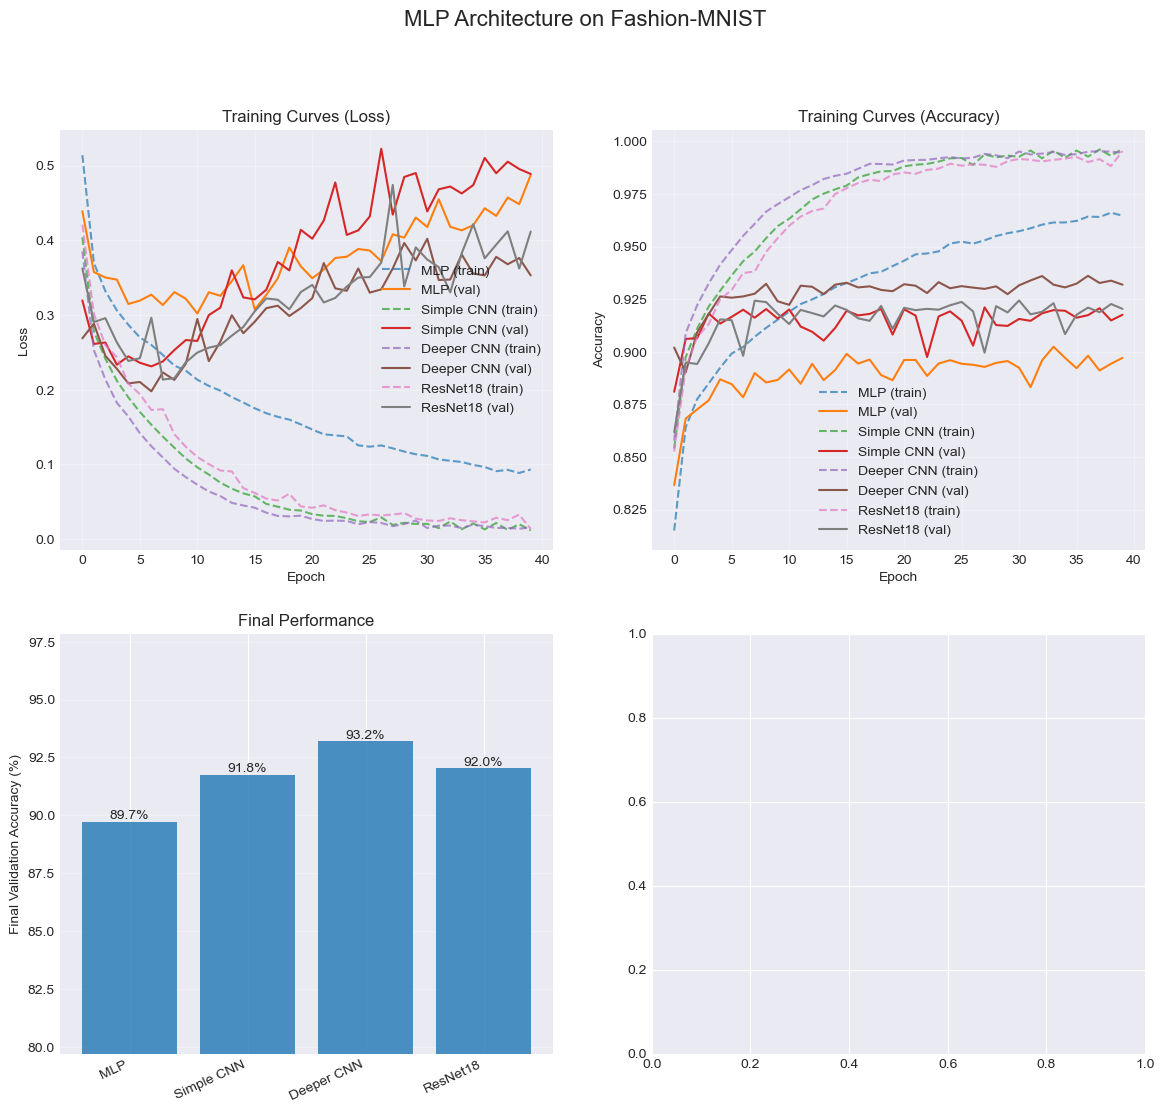

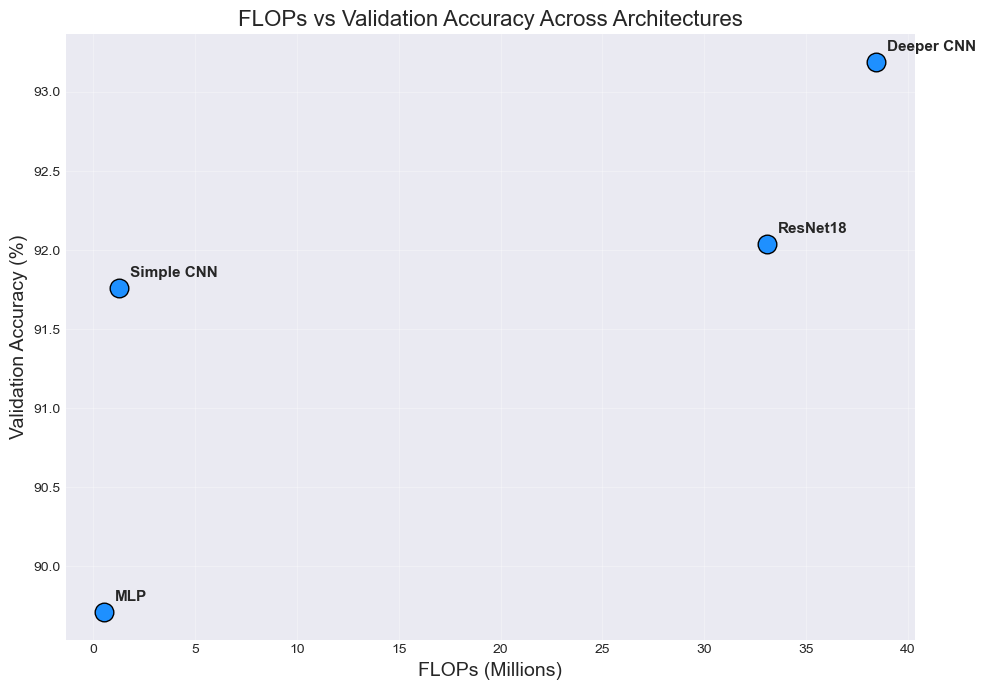


===GENERATING FLOPS PER ACCURACY PLOTS===


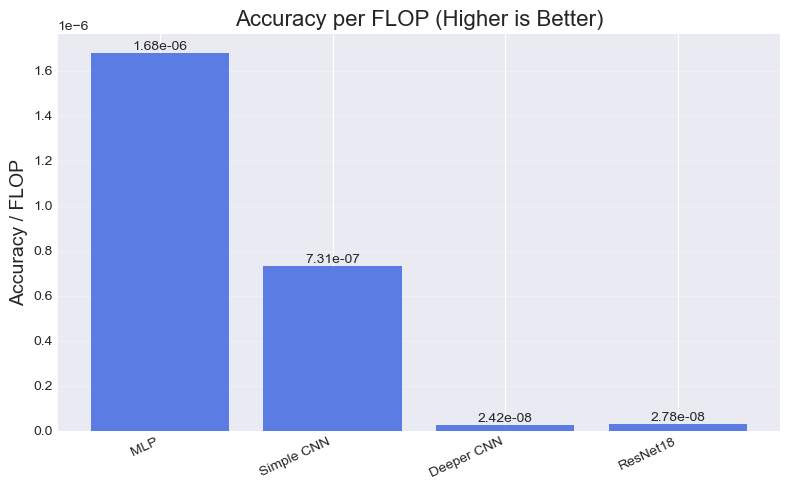


===GENERATING ACCURACY PER TRAINING SECOND===


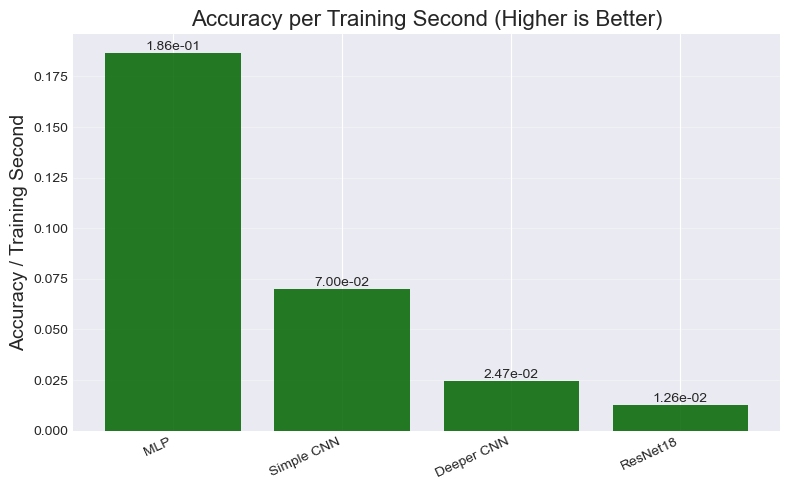


===PARETO FRONTIER CURVE===


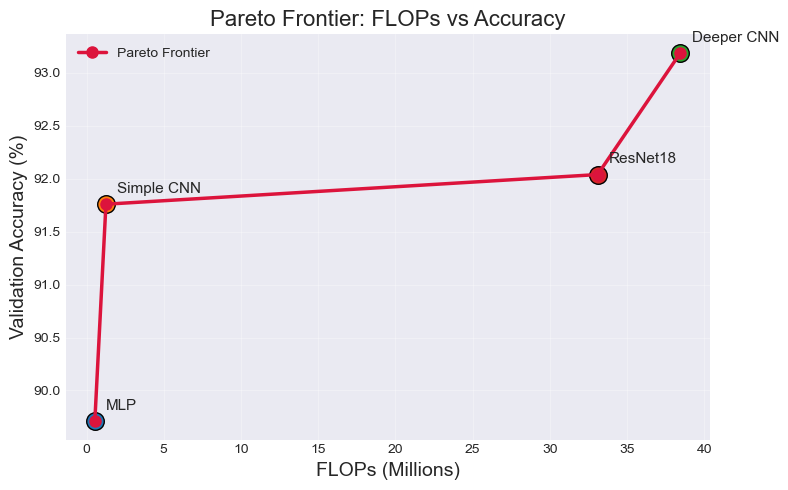


===ACCURACY VS PARAMETER COUNTS===


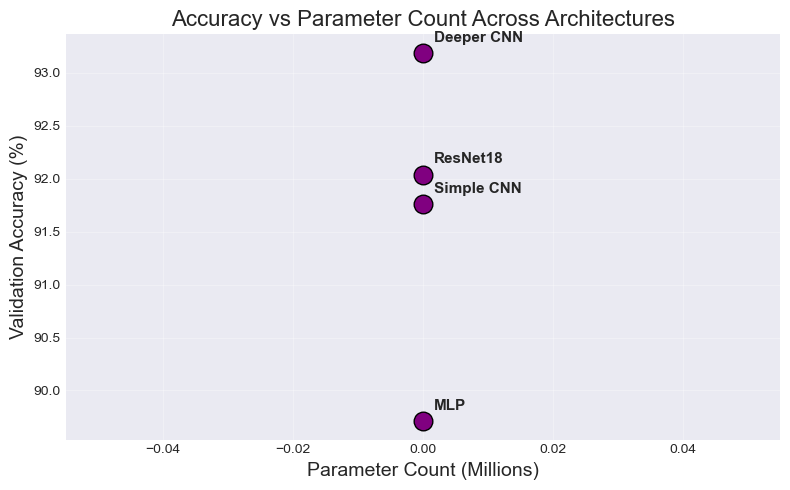


Comparison complete.


In [17]:
# get some results

def main():
    """
    Complete demonstration of MLPs, SimpleCNN, and DeeperCNN on the FashionMNIST dataset.
    """
    print("="*80)
    print("MODEL PERFORMANCES ON FASHION-MNIST")
    print("="*80)

    # 1. Load Fashion-MNIST data
    # set seed
    torch.manual_seed(42)
    print("\n1. LOADING FASHION-MNIST DATA")
    transform = transforms.Compose([transforms.ToTensor()])

    train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
    test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

    # split the training data into train and validation sets
    val_size = 10000
    train_size = len(train_dataset) - val_size
    train_ds, val_ds = random_split(train_dataset, [train_size, val_size])

    # Create DataLoaders

    train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=128, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

    # print to see the length of the datasets
    print("\n===DIMENSIONS OF THE FASHION-MNIST DATA===")
    print(f"Training samples: {len(train_dataset)}")
    print(f"Validation samples: {len(test_dataset)}")

    # print to see the length of the datasets
    print("\n===DIMENSIONS AFTER SPLIT===")
    print(f"Training samples: train_ds = {len(train_ds)}")
    print(f"Validation samples: val_ds = {len(val_ds)}")
    print(f"Test samples: test_dataset = {len(test_dataset)}")


    # 2. Architecture comparison
    results = compare_architectures(train_loader, val_loader)

    # 3. Visualize results
    print("\n===MODEL RESULTS===")
    visualize_training_results(results)
    
    print("\n=== FLOPS VS ACCURACY ===")
    visualize_flops_vs_accuracy(results)

    print("\n===GENERATING FLOPS PER ACCURACY PLOTS===")
    plot_accuracy_per_flop(results)

    print("\n===GENERATING ACCURACY PER TRAINING SECOND===")
    plot_accuracy_per_training_second(results)
    
    print("\n===PARETO FRONTIER CURVE===")
    plot_pareto_frontier(results)

    print("\n===ACCURACY VS PARAMETER COUNTS===")
    plot_accuracy_vs_params(results)


    print("\nComparison complete.")





if __name__ == "__main__":
    main()